### V-Plot Analysis for Protein-DNA Binding Footprints
This notebook demonstrates the generation of V-plots, which visualize the relationship between fragment length and distance from the binding site center.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Parsing BED File
The BED file contains information about binding sites and fragments. The center of the binding site (C1) and the fragment center (C2) are used to calculate the distance (X) and fragment length (Y).

In [6]:
def parse_bed(file_path):
    data = []
    with open(file_path, 'r') as file:
        for line in file:
            cols = line.strip().split('\t')
            chr1, start1, end1 = cols[1], int(cols[2]), int(cols[3])  # Binding site (C1)
            chr2, start2, end2 = cols[7], int(cols[8]), int(cols[9])  # Fragment (C2)
            
            center_binding = (start1 + end1) / 2
            center_fragment = (start2 + end2) / 2
            distance = center_fragment - center_binding
            fragment_length = end2 - start2
            data.append((distance, fragment_length))
    
    return pd.DataFrame(data, columns=['Distance', 'FragmentLength'])

data_frame = parse_bed("mapped.bed")

### Aggregating Frequencies
Group the data by distance (X) and fragment length (Y) to calculate the frequency (Z) for each pair.

In [7]:
heatmap_data = data_frame.groupby(['Distance', 'FragmentLength']).size().reset_index(name='Frequency')

### Generating the V-Plot Heatmap
The heatmap visualizes the frequency of fragment lengths at various distances from the binding site center.

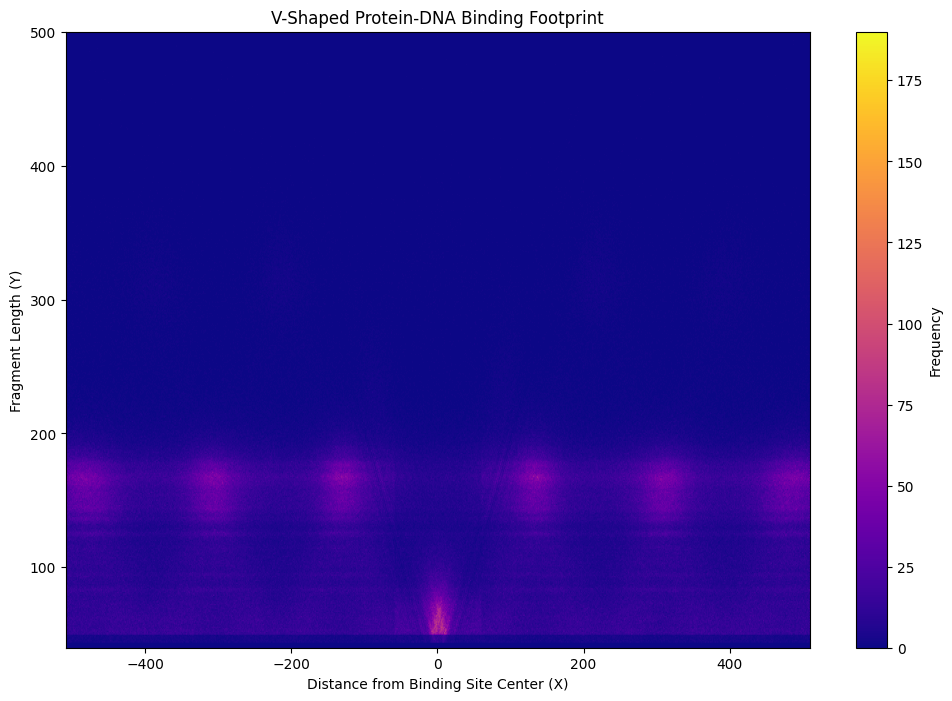

In [ ]:
pivot_table = heatmap_data.pivot(index='FragmentLength', columns='Distance', values='Frequency').fillna(0)

plt.figure(figsize=(12, 8))
plt.imshow(
    pivot_table.values,
    cmap='plasma', 
    aspect='auto',
    extent=[pivot_table.columns.min(), pivot_table.columns.max(), pivot_table.index.max(), pivot_table.index.min()]
)
plt.colorbar(label='Frequency')
plt.xlabel('Distance from Binding Site Center (X)')
plt.ylabel('Fragment Length (Y)')
plt.title('V-Shaped Protein-DNA Binding Footprint')
plt.gca().invert_yaxis()
plt.show()